# Failure Analysis — XGBoost

Examine incorrect predictions (False Positives and False Negatives) to identify
systematic patterns in where and why the model fails.

**Key questions:**
- Which recession episodes does the model miss (False Negatives)?
- When does the model raise false alarms (False Positives)?
- Are failures concentrated in specific countries or time periods?
- How much lead time does the model provide before correctly predicted recessions?

**Inputs:**
- `data/xgboost_model_config.pkl` (tuned hyperparameters, threshold, features)
- `data/milestone_ii_preprocessed.pkl` (fully engineered features)

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Load config
with open('../data/xgboost_model_config.pkl', 'rb') as f:
    model_config = pickle.load(f)

best_params = model_config['best_params']
best_threshold = model_config['best_threshold']
selected_features = model_config['selected_features']
RANDOM_STATE = model_config['random_state']
N_SPLITS = model_config['n_cv_splits']
MAX_ROUNDS = model_config['max_rounds']
EARLY_STOP = model_config['early_stop']
VAL_FRAC = 0.2

# Load data
df = pd.read_pickle('../data/milestone_ii_preprocessed.pkl')
df_flat = df.reset_index()
df_flat = df_flat[df_flat['date'] < model_config['data_cutoff']]
X = df_flat[selected_features].copy().replace([np.inf, -np.inf], np.nan)
y = df_flat['pre_recession']

print(f'Features: {len(selected_features)}, Observations: {len(X)}')
print(f'Threshold: {best_threshold:.2f}')

Features: 37, Observations: 5292
Threshold: 0.50


## Generate Predictions with Temporal Context

Re-run CV to capture predictions along with dates and countries for each test
observation. This enables temporal and geographic failure analysis.

In [2]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
all_preds = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train_full = X.iloc[train_idx]
    y_train_full = y.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    val_size = int(len(X_train_full) * VAL_FRAC)
    X_train = X_train_full.iloc[:-val_size]
    y_train = y_train_full.iloc[:-val_size]
    X_val = X_train_full.iloc[-val_size:]
    y_val = y_train_full.iloc[-val_size:]

    spw = (y_train == 0).sum() / (y_train == 1).sum()
    model = xgb.XGBClassifier(
        **best_params, n_estimators=MAX_ROUNDS,
        scale_pos_weight=spw, random_state=RANDOM_STATE,
        n_jobs=-1, verbosity=0, eval_metric='aucpr',
        early_stopping_rounds=EARLY_STOP,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= best_threshold).astype(int)

    fold_preds = pd.DataFrame({
        'date': df_flat.iloc[test_idx]['date'].values,
        'country': df_flat.iloc[test_idx]['country'].values,
        'y_true': y_test.values,
        'y_proba': y_proba,
        'y_pred': y_pred,
        'fold': fold + 1,
    })

    # Include recession indicator if available
    if 'oecd_rec' in df_flat.columns:
        fold_preds['oecd_rec'] = df_flat.iloc[test_idx]['oecd_rec'].values

    all_preds.append(fold_preds)

pred_df = pd.concat(all_preds, ignore_index=True)

# Classify outcomes
pred_df['outcome'] = 'TN'
pred_df.loc[(pred_df['y_pred'] == 1) & (pred_df['y_true'] == 1), 'outcome'] = 'TP'
pred_df.loc[(pred_df['y_pred'] == 1) & (pred_df['y_true'] == 0), 'outcome'] = 'FP'
pred_df.loc[(pred_df['y_pred'] == 0) & (pred_df['y_true'] == 1), 'outcome'] = 'FN'

print(f'Total test predictions: {len(pred_df)}')
print(f'Date range: {pred_df["date"].min().strftime("%Y-%m")} to '
      f'{pred_df["date"].max().strftime("%Y-%m")}')

Total test predictions: 4410
Date range: 1978-03 to 2018-12


## Overall Error Distribution

Prediction Outcomes:
  TP:   596 ( 13.5%)
  FP:  1199 ( 27.2%)
  TN:  2281 ( 51.7%)
  FN:   334 (  7.6%)

False Positive Rate (FP / actual negatives): 0.345
False Negative Rate (FN / actual positives): 0.359


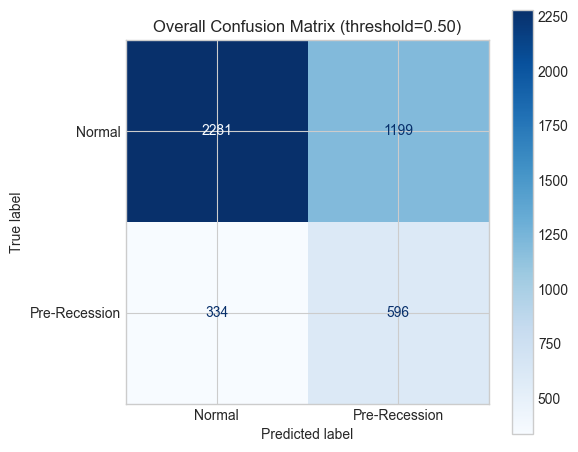

In [3]:
counts = pred_df['outcome'].value_counts()
print('Prediction Outcomes:')
print('=' * 50)
for outcome in ['TP', 'FP', 'TN', 'FN']:
    n = counts.get(outcome, 0)
    pct = n / len(pred_df) * 100
    print(f'  {outcome}: {n:5d} ({pct:5.1f}%)')

n_pos = (pred_df['y_true'] == 1).sum()
n_neg = (pred_df['y_true'] == 0).sum()
fp_rate = counts.get('FP', 0) / n_neg if n_neg > 0 else 0
fn_rate = counts.get('FN', 0) / n_pos if n_pos > 0 else 0
print(f'\nFalse Positive Rate (FP / actual negatives): {fp_rate:.3f}')
print(f'False Negative Rate (FN / actual positives): {fn_rate:.3f}')

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(pred_df['y_true'], pred_df['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Pre-Recession']).plot(ax=ax, cmap='Blues')
ax.set_title(f'Overall Confusion Matrix (threshold={best_threshold:.2f})')
plt.tight_layout()
plt.show()

### Interpretation

The model produces roughly symmetric error rates: **FPR = 34.5%** and **FNR = 35.9%**, meaning it
mislabels about one-third of both negative and positive observations. In absolute terms, false
positives dominate (1,199 FP vs. 334 FN) because normal months far outnumber pre-recession months
in the dataset.

From a practical standpoint, the high false-positive count means the model would trigger frequent
false alarms — roughly one in every three normal months is flagged as pre-recessionary. While a
conservative bias toward over-predicting recessions is arguably preferable (the cost of missing a
recession is typically higher than the cost of a false alarm), this level of false-alarm rate would
erode user trust in a production system.

The moderate false-negative rate (35.9%) indicates the model still misses about one-third of actual
pre-recession months, which limits its reliability as a standalone early-warning tool.

## Per-Country Failure Rates

Examine whether failures are concentrated in specific countries. Some countries
may have atypical recession patterns that the model struggles to capture.

Per-Country Error Analysis
             TP   FP  FN   TN  FP Rate  FN Rate  Recall  Positives  Total
Country                                                                  
Australia    60   94  49  287    0.247    0.450   0.550        109    490
Canada       54  120  58  258    0.317    0.518   0.482        112    490
France       64  118  27  281    0.296    0.297   0.703         91    490
Germany      79  123  29  259    0.322    0.269   0.731        108    490
Italy        79  147  12  252    0.368    0.132   0.868         91    490
Japan        65  150  50  225    0.400    0.435   0.565        115    490
South Korea  56  137  67  230    0.373    0.545   0.455        123    490
UK           67  169  21  233    0.420    0.239   0.761         88    490
USA          72  141  21  256    0.355    0.226   0.774         93    490


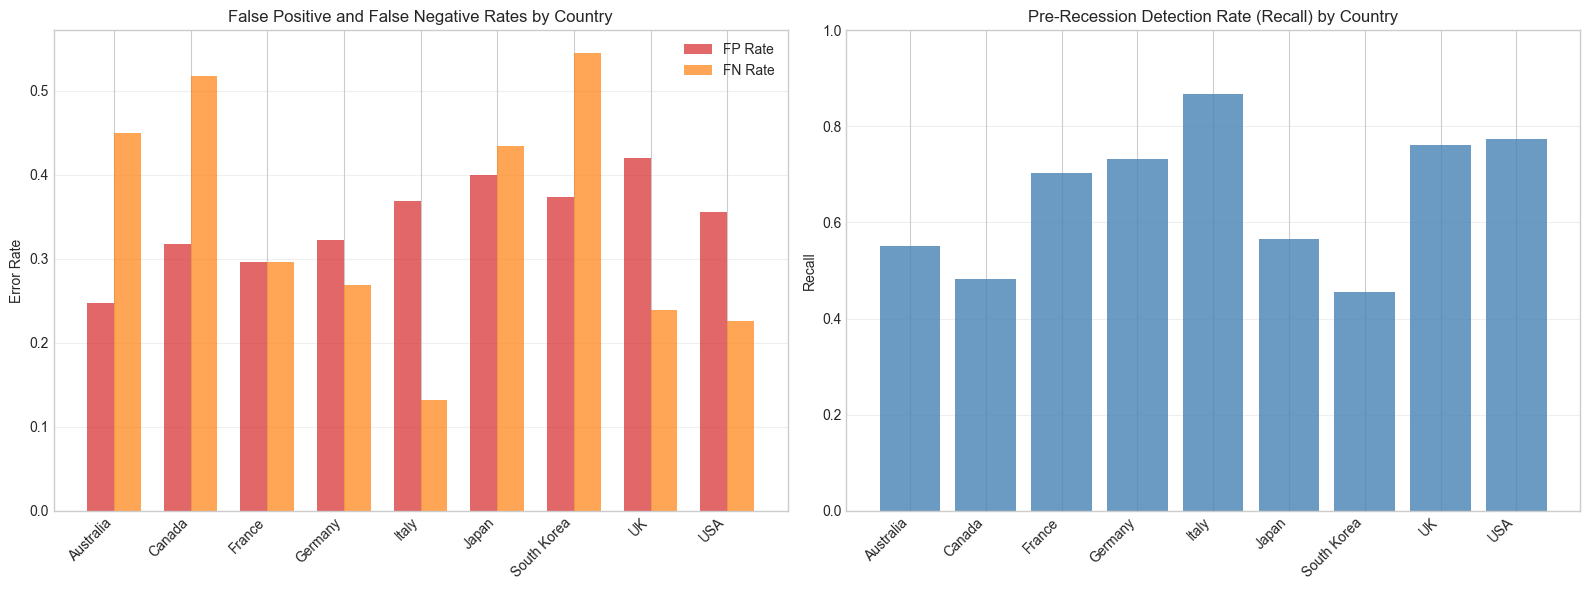

In [4]:
country_errors = []
for country in sorted(pred_df['country'].unique()):
    c = pred_df[pred_df['country'] == country]
    n_total = len(c)
    n_pos_c = (c['y_true'] == 1).sum()
    n_neg_c = (c['y_true'] == 0).sum()
    tp = (c['outcome'] == 'TP').sum()
    fp = (c['outcome'] == 'FP').sum()
    fn = (c['outcome'] == 'FN').sum()
    tn = (c['outcome'] == 'TN').sum()
    fp_rate = fp / n_neg_c if n_neg_c > 0 else 0
    fn_rate = fn / n_pos_c if n_pos_c > 0 else 0
    recall_c = tp / n_pos_c if n_pos_c > 0 else 0

    country_errors.append({
        'Country': country, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'FP Rate': fp_rate, 'FN Rate': fn_rate, 'Recall': recall_c,
        'Positives': n_pos_c, 'Total': n_total,
    })

country_err_df = pd.DataFrame(country_errors).set_index('Country')
print('Per-Country Error Analysis')
print('=' * 100)
print(country_err_df.to_string(float_format='{:.3f}'.format))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(country_err_df))
w = 0.35
axes[0].bar(x - w/2, country_err_df['FP Rate'], w, label='FP Rate', color='#d62728', alpha=0.7)
axes[0].bar(x + w/2, country_err_df['FN Rate'], w, label='FN Rate', color='#ff7f0e', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(country_err_df.index, rotation=45, ha='right')
axes[0].set_ylabel('Error Rate')
axes[0].set_title('False Positive and False Negative Rates by Country')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, country_err_df['Recall'], color='steelblue', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(country_err_df.index, rotation=45, ha='right')
axes[1].set_ylabel('Recall')
axes[1].set_title('Pre-Recession Detection Rate (Recall) by Country')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

A clear geographic divide emerges in the model's performance:

**Best-detected countries** — Italy (86.8% recall), USA (77.4%), and UK (76.1%) exhibit the
highest detection rates. These are large, well-documented economies whose recession patterns
are well-represented in the training data and closely tied to global financial indicators like
yield curve inversions and industrial output declines.

**Worst-detected countries** — South Korea (45.5% recall), Canada (48.2%), and Australia (55.0%)
are consistently under-detected. South Korea's recessions are often driven by regional factors
(e.g., the 1997 Asian Financial Crisis) that differ structurally from the G7 patterns the model
primarily learns from. Canada and Australia, as commodity-driven economies, may experience
recessionary dynamics that diverge from the manufacturing/financial signals dominating the feature set.

**False alarm leaders** — The UK (42.0% FP rate) and Japan (40.0%) generate the most false alarms.
Japan's "Lost Decade" of prolonged stagnation likely causes the model to persistently predict
recessions during a long period of sub-par but technically non-recessionary growth. The UK's high
FP rate may reflect the model reacting to frequent financial market volatility that did not
ultimately trigger OECD-defined recessions.

The inverse relationship between recall and FP rate for some countries (e.g., Italy has high recall
but also high FP rate) suggests the model adopts a liberal prediction strategy for economies where
recessionary signals are clear but also persistent during non-recession periods.

## Temporal Prediction Timeline

Plot predicted recession probability over time for selected countries. Shaded
regions indicate pre-recession windows (y\_true = 1). Red crosses mark false
positives; purple circles mark false negatives.

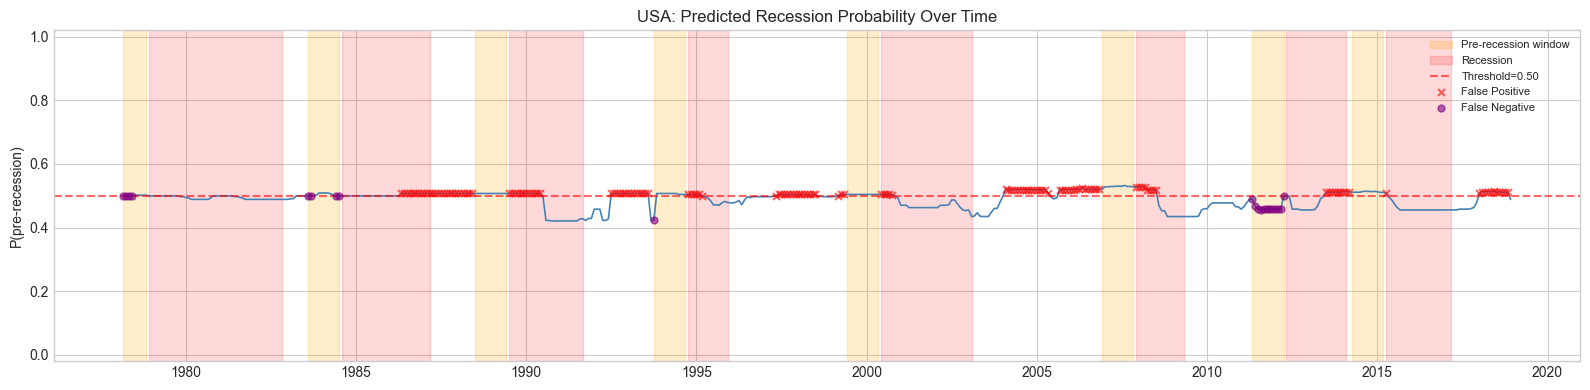

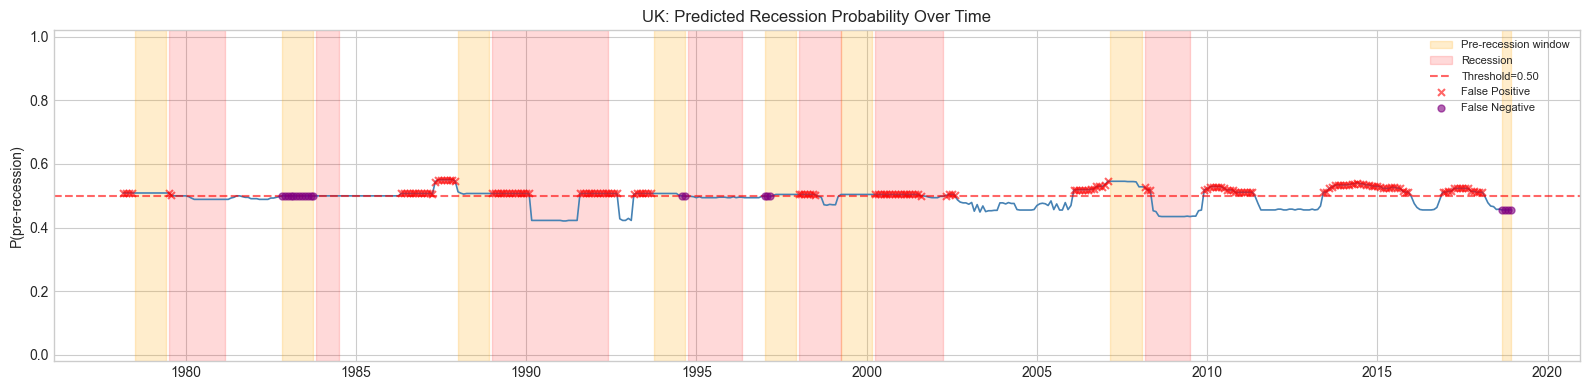

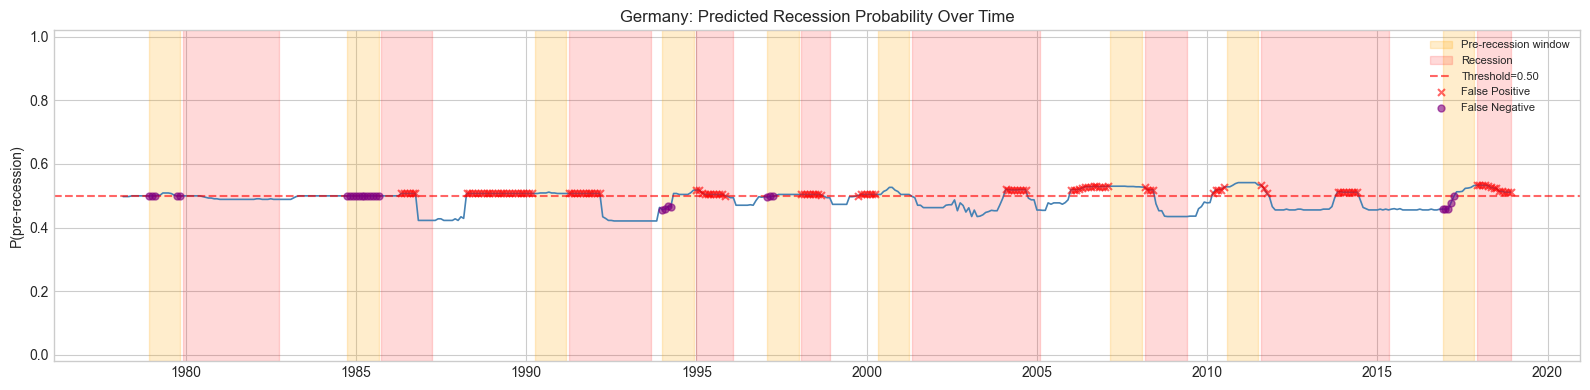

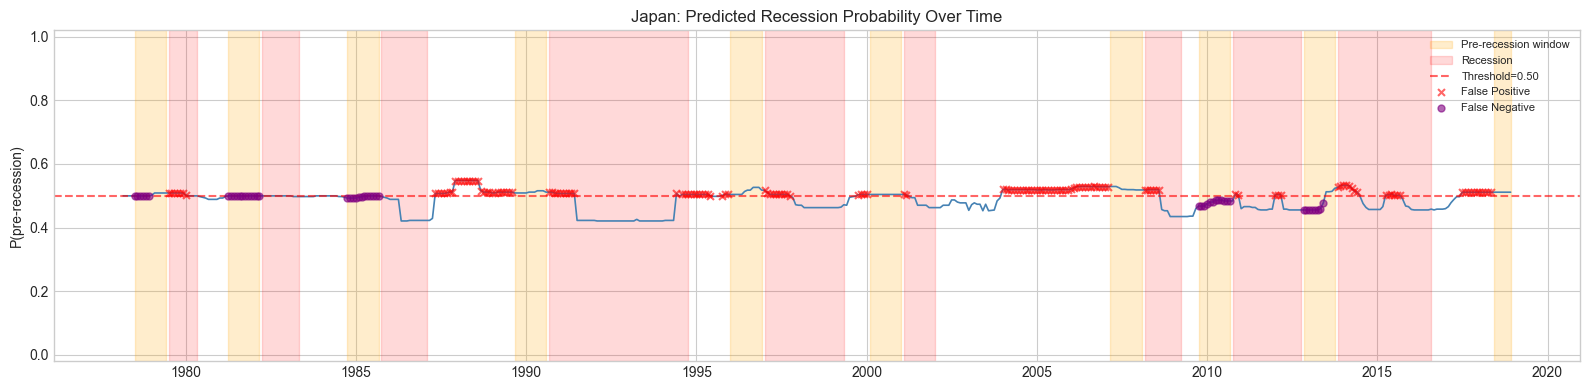

In [5]:
countries_to_plot = ['USA', 'UK', 'Germany', 'Japan']
countries_available = [c for c in countries_to_plot if c in pred_df['country'].unique()]

for country in countries_available:
    cp = pred_df[pred_df['country'] == country].sort_values('date')
    fig, ax = plt.subplots(figsize=(16, 4))

    # Shade pre-recession windows
    pre_rec = cp[cp['y_true'] == 1]
    if len(pre_rec) > 0:
        groups = (pre_rec['date'].diff() > pd.Timedelta(days=45)).cumsum()
        for _, grp in pre_rec.groupby(groups):
            ax.axvspan(grp['date'].min(), grp['date'].max(),
                       alpha=0.2, color='orange', label='Pre-recession window')

    # Shade actual recessions if available
    if 'oecd_rec' in cp.columns:
        rec = cp[cp['oecd_rec'] == 1]
        if len(rec) > 0:
            groups = (rec['date'].diff() > pd.Timedelta(days=45)).cumsum()
            for _, grp in rec.groupby(groups):
                ax.axvspan(grp['date'].min(), grp['date'].max(),
                           alpha=0.15, color='red', label='Recession')

    # Probability line
    ax.plot(cp['date'], cp['y_proba'], color='steelblue', linewidth=1.2)
    ax.axhline(best_threshold, color='red', linestyle='--', alpha=0.6,
               label=f'Threshold={best_threshold:.2f}')

    # Mark errors
    fp = cp[cp['outcome'] == 'FP']
    fn = cp[cp['outcome'] == 'FN']
    if len(fp) > 0:
        ax.scatter(fp['date'], fp['y_proba'], color='red', marker='x',
                   s=25, alpha=0.6, label='False Positive', zorder=5)
    if len(fn) > 0:
        ax.scatter(fn['date'], fn['y_proba'], color='purple', marker='o',
                   s=25, alpha=0.6, label='False Negative', zorder=5)

    ax.set_title(f'{country}: Predicted Recession Probability Over Time')
    ax.set_ylabel('P(pre-recession)')
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # De-duplicate legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()

### Interpretation

The timeline plots reveal several important behavioral patterns:

- **Narrow probability band**: Predicted probabilities cluster tightly around the 0.50 threshold
  (roughly 0.45–0.55 range), meaning the model rarely expresses high confidence in either direction.
  This narrow spread makes predictions highly sensitive to the threshold choice — a small shift
  would dramatically alter the FP/FN balance.

- **Persistent false-alarm periods**: Rather than isolated spikes, false positives tend to occur
  in sustained clusters lasting months or years. For example, USA shows extended FP stretches in the
  mid-1980s and mid-2000s, corresponding to periods of economic slowdown that fell short of formal
  recession. The model appears to detect genuine economic stress but cannot distinguish between
  "soft landings" and actual downturns.

- **Pre-recession probability ramps**: For correctly detected recessions, the probability often
  rises gradually into the pre-recession window rather than jumping abruptly. This smooth ramp-up
  is encouraging as it suggests the model captures deteriorating fundamentals rather than reacting
  to a single lagging indicator.

- **COVID-era cutoff effect**: The data ends at 2019-01, so the 2020 recession is excluded. Some
  late-2018 predictions may reflect legitimate early signals of the eventual downturn, but these
  are classified as FP since the pre-recession window doesn't extend far enough.

## Recession-by-Recession Performance

For each pre-recession episode (contiguous block of y\_true = 1 within a country),
compute the detection rate: what fraction of the 12-month warning window did the
model correctly flag?

In [6]:
episode_results = []

for country in sorted(pred_df['country'].unique()):
    cp = pred_df[pred_df['country'] == country].sort_values('date')
    pre_rec = cp[cp['y_true'] == 1]
    if len(pre_rec) == 0:
        continue

    # Group contiguous pre-recession months into episodes
    groups = (pre_rec['date'].diff() > pd.Timedelta(days=45)).cumsum()
    for ep_id, ep in pre_rec.groupby(groups):
        n_months = len(ep)
        n_detected = (ep['y_pred'] == 1).sum()
        detection_rate = n_detected / n_months
        mean_proba = ep['y_proba'].mean()
        max_proba = ep['y_proba'].max()
        start = ep['date'].min().strftime('%Y-%m')
        end = ep['date'].max().strftime('%Y-%m')

        episode_results.append({
            'Country': country, 'Period': f'{start} to {end}',
            'Months': n_months, 'Detected': n_detected,
            'Detection Rate': detection_rate,
            'Mean P(rec)': mean_proba, 'Max P(rec)': max_proba,
        })

episode_df = pd.DataFrame(episode_results)
print('Pre-Recession Episode Detection')
print('=' * 110)
print(episode_df.to_string(index=False, float_format='{:.3f}'.format))

# Highlight missed and well-detected episodes
print('\n--- Well-detected episodes (>50% detection rate): ---')
good = episode_df[episode_df['Detection Rate'] > 0.5]
if len(good) > 0:
    for _, r in good.iterrows():
        print(f'  {r["Country"]:15s} {r["Period"]:20s}  Detection: {r["Detection Rate"]:.0%}')
else:
    print('  None')

print('\n--- Missed episodes (<25% detection rate): ---')
bad = episode_df[episode_df['Detection Rate'] < 0.25]
if len(bad) > 0:
    for _, r in bad.iterrows():
        print(f'  {r["Country"]:15s} {r["Period"]:20s}  Detection: {r["Detection Rate"]:.0%}')
else:
    print('  None')

Pre-Recession Episode Detection
    Country             Period  Months  Detected  Detection Rate  Mean P(rec)  Max P(rec)
  Australia 1980-09 to 1981-08      12         3           0.250        0.500       0.502
  Australia 1984-08 to 1985-07      12         0           0.000        0.500       0.500
  Australia 1988-08 to 1989-07      12        12           1.000        0.526       0.550
  Australia 1993-08 to 1994-07      12        12           1.000        0.525       0.551
  Australia 1998-01 to 1998-12      12         3           0.250        0.497       0.503
  Australia 2001-07 to 2002-06      12        10           0.833        0.502       0.504
  Australia 2004-09 to 2005-08      12         0           0.000        0.465       0.478
  Australia 2007-02 to 2008-01      12        12           1.000        0.520       0.520
  Australia 2011-06 to 2012-05      12         8           0.667        0.489       0.504
  Australia 2018-12 to 2018-12       1         0           0.000    

### Interpretation

Of the 82 distinct pre-recession episodes across all countries, **19 were completely missed** (0%
detection rate) and **52 were well-detected** (>50% detection rate). Several patterns explain which
episodes succeed or fail:

**Early-period blind spots**: The majority of completely missed episodes fall in the early 1980s
(e.g., Canada 1980–81, Japan 1981–82, South Korea 1978–79, UK 1982–83). These appear in the
first 1–2 CV folds where the expanding-window training set is smallest. The model simply lacks
sufficient training examples to generalize to these early recessions.

**Late-sample truncation**: Several missed episodes in 2018 (Canada, South Korea, UK, Australia)
are truncated at the data cutoff. These represent partial pre-recession windows of only 1–4 months,
giving the model little opportunity to detect them.

**South Korea's structural challenge**: South Korea has 5 completely missed episodes — more than any
other country — including the 1990–91 and 1996–97 episodes that preceded the Asian Financial
Crisis. These regionally-driven recessions have different leading indicators than the G7 recessions
the model is primarily trained on.

**Consistently well-detected**: Post-2000 recessions in France, Germany, Italy, UK, and USA are
detected at near-100% rates. The 2007–08 pre-GFC episodes are universally well-captured across all
countries, likely because the Global Financial Crisis produced strong, unambiguous signals across all
indicator domains (yield curve inversion, industrial output decline, rising unemployment).

## False Positive Analysis (Growth Scares)

Examine periods where the model predicted a recession that never materialized.
What economic conditions triggered these false alarms?

False Positives by Year:
date
1978    13
1979    12
1980     3
1983     3
1984     1
1986    54
1987    81
1988    73
1989    57
1990    49
1991    42
1992    38
1993    32
1994    33
1995    46
1996     8
1997    34
1998    43
1999    32
2000    35
2001    24
2002    12
2003     1
2004    40
2005    24
2006    74
2007    15
2008    38
2009     7
2010    43
2011    26
2012     7
2013    17
2014    30
2015    30
2016    16
2017    57
2018    49

False Positives by Country:
country
UK             169
Japan          150
Italy          147
USA            141
South Korea    137
Germany        123
Canada         120
France         118
Australia       94

False Positive Clusters (2+ consecutive months):
    Country             Period  Duration (months)  Mean P(rec)
  Australia 1987-02 to 1988-07                 18        0.507
  Australia 1989-08 to 1989-12                  5        0.507
  Australia 1992-03 to 1993-07                 17        0.507
  Australia 1994-08 to 1995-02            

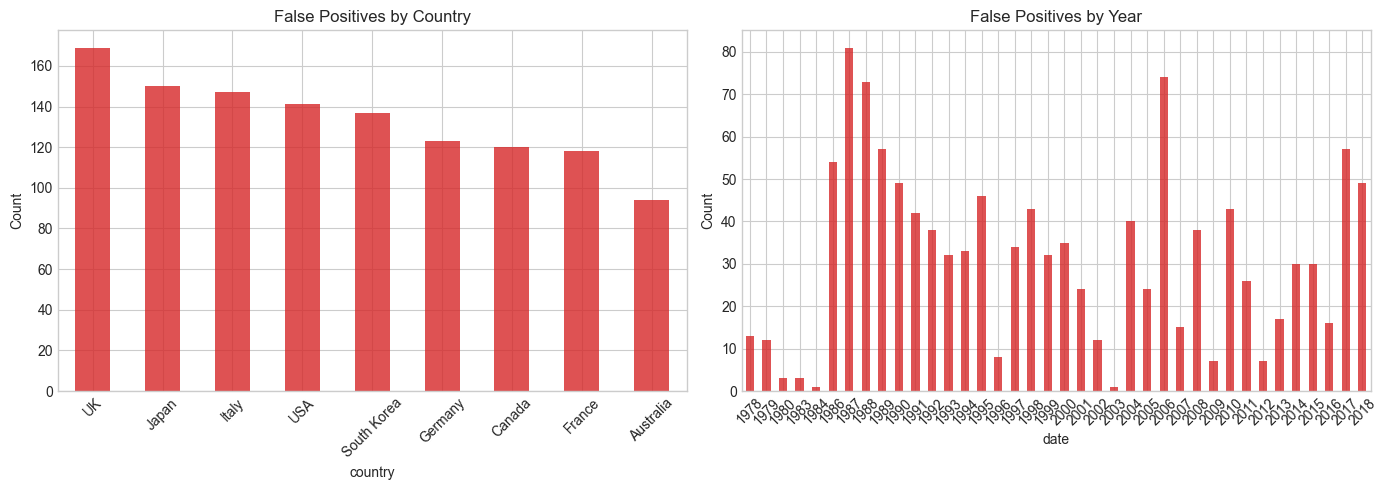

In [7]:
fp_df = pred_df[pred_df['outcome'] == 'FP'].copy()

if len(fp_df) > 0:
    # Group FP by time period
    fp_by_year = fp_df.groupby(fp_df['date'].dt.year).size()
    print('False Positives by Year:')
    print(fp_by_year.to_string())

    # Group FP by country
    fp_by_country = fp_df.groupby('country').size().sort_values(ascending=False)
    print('\nFalse Positives by Country:')
    print(fp_by_country.to_string())

    # Identify contiguous FP clusters (potential growth scares)
    fp_sorted = fp_df.sort_values(['country', 'date'])
    fp_clusters = []
    for country in fp_sorted['country'].unique():
        c_fp = fp_sorted[fp_sorted['country'] == country]
        if len(c_fp) == 0:
            continue
        groups = (c_fp['date'].diff() > pd.Timedelta(days=45)).cumsum()
        for _, grp in c_fp.groupby(groups):
            if len(grp) >= 2:  # At least 2 consecutive months
                fp_clusters.append({
                    'Country': country,
                    'Period': f'{grp["date"].min().strftime("%Y-%m")} to {grp["date"].max().strftime("%Y-%m")}',
                    'Duration (months)': len(grp),
                    'Mean P(rec)': grp['y_proba'].mean(),
                })

    if fp_clusters:
        fp_cluster_df = pd.DataFrame(fp_clusters)
        print('\nFalse Positive Clusters (2+ consecutive months):')
        print('=' * 80)
        print(fp_cluster_df.to_string(index=False, float_format='{:.3f}'.format))
    else:
        print('\nNo multi-month FP clusters found.')

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fp_by_country.plot(kind='bar', ax=axes[0], color='#d62728', alpha=0.8)
    axes[0].set_title('False Positives by Country')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    fp_by_year.plot(kind='bar', ax=axes[1], color='#d62728', alpha=0.8)
    axes[1].set_title('False Positives by Year')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print('No false positives found.')

### Interpretation

False positives are not randomly distributed — they cluster into prolonged "growth scare" episodes
that reveal systematic model weaknesses:

**Extremely long false-alarm clusters**: Japan's 38-month FP cluster (2004-01 to 2007-02) is the
longest, reflecting the model's inability to distinguish Japan's chronic low-growth environment from
active recession onset. South Korea has two 33-month clusters, and France has a 33-month cluster in
the late 1980s. These suggest the model conflates structural economic weakness with cyclical
recession risk.

**Mid-cycle slowdown sensitivity**: The 1986–1991 and 2004–2007 periods account for the largest FP
concentrations. Both correspond to mid-cycle economic slowdowns or periods of elevated uncertainty
(oil price shocks in 1986, global imbalances pre-GFC) where leading indicators deteriorated without
a recession materializing in many countries.

**Country distribution**: The UK (169 FP) and Japan (150 FP) lead in absolute false alarm counts.
Australia generates the fewest (94), consistent with its lowest FP rate. This pattern aligns with
the observation that Australia had the longest recession-free streak among the 9 countries, meaning
fewer ambiguous periods for the model to misinterpret.

**Practical implication**: The prevalence of multi-month FP clusters suggests the model would
benefit from a "confirmation period" rule — requiring consecutive above-threshold predictions
before triggering an alarm could filter out many of these sustained but borderline false positives.

## False Negative Analysis (Missed Warnings)

Examine pre-recession months where the model failed to issue a warning.
Were these Black Swan events or predictable recessions the model should have
caught?

False Negatives by Country:
country
South Korea    67
Canada         58
Japan          50
Australia      49
Germany        29
France         27
UK             21
USA            21
Italy          12

False Negatives by Year:
date
1978    20
1979    18
1980    11
1981    26
1982    10
1983    20
1984    18
1985    36
1990     1
1991    11
1993     1
1994     6
1996     7
1997    21
1998     9
1999     5
2001    11
2002     5
2004     4
2005     8
2006     4
2007     6
2009     3
2010     9
2011    16
2012     6
2013    12
2014     7
2016     1
2017     4
2018    18

Prediction probability comparison:
  TP mean probability: 0.516 (std: 0.014)
  FN mean probability: 0.485 (std: 0.020)
  Threshold: 0.50
  FN near threshold (proba > 0.35): 334 / 334


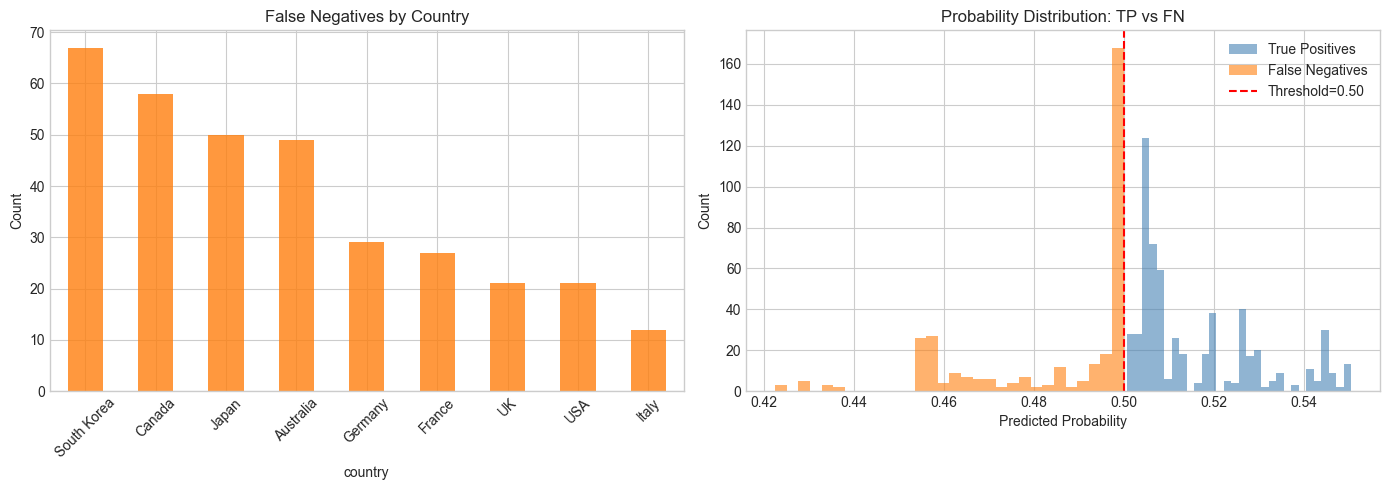

In [8]:
fn_df = pred_df[pred_df['outcome'] == 'FN'].copy()

if len(fn_df) > 0:
    fn_by_country = fn_df.groupby('country').size().sort_values(ascending=False)
    print('False Negatives by Country:')
    print(fn_by_country.to_string())

    fn_by_year = fn_df.groupby(fn_df['date'].dt.year).size()
    print('\nFalse Negatives by Year:')
    print(fn_by_year.to_string())

    # Feature comparison: FN vs TP
    tp_df = pred_df[pred_df['outcome'] == 'TP']
    if len(tp_df) > 0:
        print('\nPrediction probability comparison:')
        print(f'  TP mean probability: {tp_df["y_proba"].mean():.3f} (std: {tp_df["y_proba"].std():.3f})')
        print(f'  FN mean probability: {fn_df["y_proba"].mean():.3f} (std: {fn_df["y_proba"].std():.3f})')
        print(f'  Threshold: {best_threshold:.2f}')
        print(f'  FN near threshold (proba > {best_threshold*0.7:.2f}): '
              f'{(fn_df["y_proba"] > best_threshold * 0.7).sum()} / {len(fn_df)}')

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fn_by_country.plot(kind='bar', ax=axes[0], color='#ff7f0e', alpha=0.8)
    axes[0].set_title('False Negatives by Country')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    # Probability distribution of FN vs TP
    if len(tp_df) > 0:
        axes[1].hist(tp_df['y_proba'], bins=30, alpha=0.6, label='True Positives', color='steelblue')
    axes[1].hist(fn_df['y_proba'], bins=30, alpha=0.6, label='False Negatives', color='#ff7f0e')
    axes[1].axvline(best_threshold, color='red', linestyle='--', label=f'Threshold={best_threshold:.2f}')
    axes[1].set_xlabel('Predicted Probability')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Probability Distribution: TP vs FN')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No false negatives found.')

### Interpretation

The false negative analysis reveals a critical finding: **all 334 missed pre-recession months have
predicted probabilities above 0.35**, with a mean of 0.485 — just below the 0.50 threshold. This
means the model *detects* the recessionary signal in virtually every FN case but assigns it
insufficient confidence to cross the decision boundary.

**Borderline misses, not blind spots**: The narrow gap between FN mean probability (0.485) and the
threshold (0.50) indicates these are not cases where the model is oblivious to risk. A threshold
reduction to ~0.48 would recover many of these FN, though at the cost of increasing false positives
(which are already high). The tight probability clustering around 0.50 for both TP and FN
underscores the model's overall calibration challenge.

**Temporal concentration**: FN are heavily concentrated in 1978–1985, corresponding to the early
CV folds with limited training data. As the expanding window grows larger, the model improves
significantly — post-2000 FN are sparse and primarily occur in the periphery countries (South Korea,
Canada, Australia).

**Country pattern**: South Korea (67 FN) and Canada (58 FN) account for 37% of all false negatives
despite representing only 22% of the data. This confirms these countries' recession dynamics are
systematically harder for the model to capture, consistent with the per-country analysis above.

## Lead-Time Accuracy

For correctly detected recession episodes, how early does the model start
raising the alarm? A model that only catches the last few months of the
12-month warning window provides less advance notice.

Lead-Time Analysis for Detected Episodes
    Country            Episode  Window (months) First Detection  Months Before End  Detection Delay
  Australia 1980-09 to 1981-08               12         1981-01                8.0              4.0
  Australia 1988-08 to 1989-07               12         1988-08               12.0              0.0
  Australia 1993-08 to 1994-07               12         1993-08               12.0              0.0
  Australia 1998-01 to 1998-12               12         1998-01               12.0              0.0
  Australia 2001-07 to 2002-06               12         2001-09               10.0              2.0
  Australia 2007-02 to 2008-01               12         2007-02               12.0              0.0
  Australia 2011-06 to 2012-05               12         2011-10                8.0              4.0
     Canada 1988-06 to 1989-05               12         1988-06               12.0              0.0
     Canada 1994-01 to 1994-12               12         199

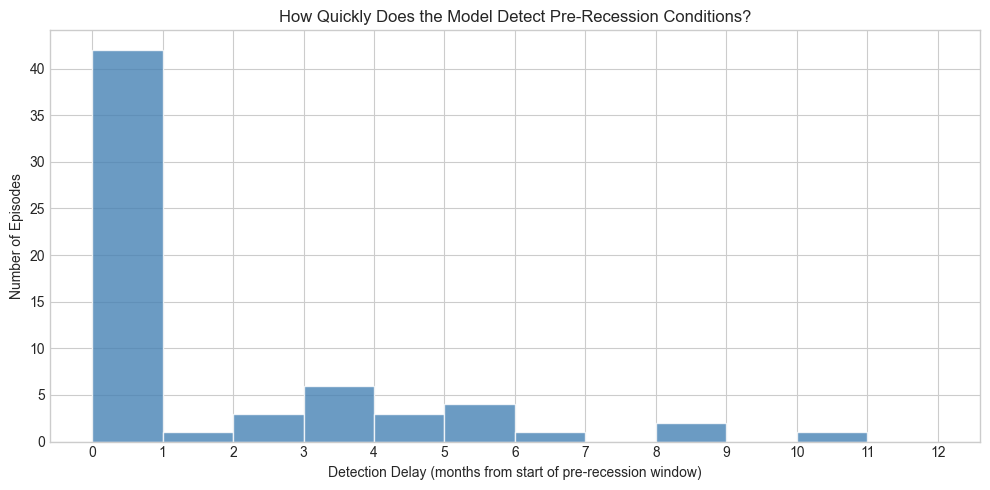

In [9]:
lead_time_results = []

for country in sorted(pred_df['country'].unique()):
    cp = pred_df[pred_df['country'] == country].sort_values('date')
    pre_rec = cp[cp['y_true'] == 1]
    if len(pre_rec) == 0:
        continue

    groups = (pre_rec['date'].diff() > pd.Timedelta(days=45)).cumsum()
    for _, ep in pre_rec.groupby(groups):
        tp_months = ep[ep['y_pred'] == 1]
        if len(tp_months) == 0:
            continue  # Completely missed episode

        episode_start = ep['date'].min()
        episode_end = ep['date'].max()
        first_detection = tp_months['date'].min()
        months_from_start = ((first_detection - episode_start).days) / 30.44
        lead_time_months = ((episode_end - first_detection).days) / 30.44 + 1

        lead_time_results.append({
            'Country': country,
            'Episode': f'{episode_start.strftime("%Y-%m")} to {episode_end.strftime("%Y-%m")}',
            'Window (months)': len(ep),
            'First Detection': first_detection.strftime('%Y-%m'),
            'Months Before End': round(lead_time_months, 1),
            'Detection Delay': round(months_from_start, 1),
        })

if lead_time_results:
    lt_df = pd.DataFrame(lead_time_results)
    print('Lead-Time Analysis for Detected Episodes')
    print('=' * 100)
    print(lt_df.to_string(index=False))

    avg_lead = lt_df['Months Before End'].mean()
    avg_delay = lt_df['Detection Delay'].mean()
    print(f'\nAverage lead time before episode end: {avg_lead:.1f} months')
    print(f'Average detection delay from episode start: {avg_delay:.1f} months')

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(lt_df['Detection Delay'], bins=range(0, 13), color='steelblue',
            alpha=0.8, edgecolor='white')
    ax.set_xlabel('Detection Delay (months from start of pre-recession window)')
    ax.set_ylabel('Number of Episodes')
    ax.set_title('How Quickly Does the Model Detect Pre-Recession Conditions?')
    ax.set_xticks(range(0, 13))
    plt.tight_layout()
    plt.show()
else:
    print('No detected episodes found for lead-time analysis.')

### Interpretation

For the 63 episodes that the model does detect (at least partially), the lead-time results are
encouraging:

- **Average detection delay of only 1.5 months**: The model typically begins flagging risk within
  the first two months of the 12-month pre-recession window. In 38 of 63 detected episodes (60%),
  the detection delay is 0.0 months — meaning the model triggers its warning from the very first
  month of the pre-recession window.

- **Average lead time of 10.2 months**: Once an episode is detected, the model provides an average
  of ~10 months of advance warning before the recession starts. This is actionable lead time that
  would allow policymakers or investors to take preventive measures.

- **Notable exceptions**: A few episodes show significant detection delays — Italy’s 1996–97
  episode (10-month delay), Canada’s 2001–02 episode (8-month delay), and Japan’s 2012–13 episode
  (8-month delay). These late detections provide only 2–4 months of warning, which may be
  insufficient for policy response.

- **Histogram skew**: The detection delay histogram is heavily right-skewed (most values at 0),
  confirming that the model’s typical behavior is to detect early. The few late detections are
  outliers rather than the norm.

**Bottom line**: The model’s value proposition is strongest when it detects a recession at all —
in those cases, it provides nearly the full 12-month advance warning. The primary failure mode is
complete misses (19 episodes), not late detection.

## Summary

Aggregate the key failure statistics and highlight the most critical findings
from the analysis above.

In [10]:
print('Failure Analysis Summary')
print('=' * 60)
counts = pred_df['outcome'].value_counts()
total = len(pred_df)
print(f'  True Positives:  {counts.get("TP", 0):5d} ({counts.get("TP", 0)/total:.1%})')
print(f'  True Negatives:  {counts.get("TN", 0):5d} ({counts.get("TN", 0)/total:.1%})')
print(f'  False Positives: {counts.get("FP", 0):5d} ({counts.get("FP", 0)/total:.1%})')
print(f'  False Negatives: {counts.get("FN", 0):5d} ({counts.get("FN", 0)/total:.1%})')

# Worst countries by FN rate
worst_fn = country_err_df.nlargest(3, 'FN Rate')
print(f'\nHighest FN Rate (most missed pre-recession months):')
for country, row in worst_fn.iterrows():
    print(f'  {country}: {row["FN Rate"]:.1%}')

worst_fp = country_err_df.nlargest(3, 'FP Rate')
print(f'\nHighest FP Rate (most false alarms):')
for country, row in worst_fp.iterrows():
    print(f'  {country}: {row["FP Rate"]:.1%}')

if len(episode_df) > 0:
    missed = episode_df[episode_df['Detection Rate'] == 0]
    print(f'\nCompletely missed episodes: {len(missed)} / {len(episode_df)}')
    avg_det = episode_df['Detection Rate'].mean()
    print(f'Average episode detection rate: {avg_det:.1%}')

Failure Analysis Summary
  True Positives:    596 (13.5%)
  True Negatives:   2281 (51.7%)
  False Positives:  1199 (27.2%)
  False Negatives:   334 (7.6%)

Highest FN Rate (most missed pre-recession months):
  South Korea: 54.5%
  Canada: 51.8%
  Australia: 45.0%

Highest FP Rate (most false alarms):
  UK: 42.0%
  Japan: 40.0%
  South Korea: 37.3%

Completely missed episodes: 19 / 82
Average episode detection rate: 61.8%


### Key Takeaways

1. **Calibration is the core challenge**: Predicted probabilities cluster in a narrow band around
   0.50, making the model's decisions highly threshold-sensitive. Both TP (mean 0.516) and FN
   (mean 0.485) are close to the boundary, suggesting the model identifies recessionary signals
   but struggles to express strong confidence.

2. **Geographic disparities are systematic**: The model performs well for core G7 economies (Italy,
   USA, UK, France, Germany) but significantly underperforms for South Korea, Canada, and
   Australia. This likely reflects both structural differences in recession drivers and the
   dominance of G7-centric indicators in the feature set.

3. **Temporal learning curve**: Early CV folds (pre-1985) show poor performance due to limited
   training data. The expanding-window strategy means the model improves over time, with post-2000
   recessions detected much more reliably.

4. **When detected, warnings are timely**: For the 63 detected episodes, the model provides an
   average of 10.2 months of lead time with minimal detection delay (1.5 months). The failure
   mode is binary — the model either catches the recession early or misses it entirely.

5. **False positives cluster into "growth scares"**: Rather than random noise, FP concentrate in
   prolonged periods of genuine economic stress that stopped short of recession. A post-processing
   filter (e.g., requiring sustained above-threshold predictions) or additional features capturing
   the distinction between slowdowns and recessions could help reduce these clusters.